# Generate repeats's statitics and plots

## Load packages

In [53]:
import os
import pandas as pd
from Bio import Phylo
from io import StringIO
import re
import gffpandas.gffpandas as gffpd
from concurrent.futures import ProcessPoolExecutor

In [ ]:
# Configure Plotly renderer to avoid nbformat dependency errors in VS Code
import plotly.io as pio
pio.renderers.default = 'vscode'

## Functions

In [56]:
def format_plot_name(name):
    # Special case
    if name == "Strigamia-acuminata-3":
        name = "Strigamia-acuminata-2"
    elif name != "Strigamia-acuminata-1":
        name = re.sub(r"-1$", "-", name)

    name = name.replace('-', ' ').lower()

    # Capitalize first letter
    return name.capitalize()


In [77]:
# Reusable styling function for Seaborn/Matplotlib plots
import matplotlib.pyplot as plt
import seaborn as sns

def style_seaborn(ax, *, title=None, subtitle=None, xlabel=None, ylabel=None):
    """Apply standardized visual styling to a Seaborn/Matplotlib Axes.

    - Font family: Helvetica
    - Title: size 28, bold, color #222222
    - Subtitle: size 22
    - Legend text: size 18, color #222222
    - Axis tick text: size 18, color #222222
    - Axis titles: size 22, bold, color #222222
    - Panel major grid (y): lighter gray dashed behind bars
    - Remove frame/spines around the plot
    """
    # # Global font family
    # plt.rcParams['font.family'] = 'Helvetica'

    # Axis titles
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=22, fontweight='bold', color='#222222')
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=22, fontweight='bold', color='#222222')

    # Axis tick labels (keep labels but remove tick marks)
    ax.tick_params(axis='both', labelsize=18, colors='#222222', length=0)

    # Main title
    if title is not None:
        ax.set_title(title, fontsize=28, fontweight='bold', color='#222222', pad=12)

    # Subtitle (placed just below the top of the axes)
    if subtitle:
        ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha='center', va='bottom',
                fontsize=22, color='#222222')

    # Ensure grid lines render behind bars
    ax.set_axisbelow(True)

    # Grid on Y only: lighter gray dashed
    ax.grid(axis='y', color='#e0e0e0', linewidth=1.0, linestyle='--')

    # Remove all spines (frame)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Legend styling (if present)
    leg = ax.get_legend()
    if leg is not None:
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(18)
            leg.get_title().set_color('#222222')
        for txt in leg.get_texts():
            txt.set_fontsize(18)
            txt.set_color('#222222')

    return ax

## Load files

In [57]:
work_dir = "/tempor/merlat/exogaptwo/work/plot_repeats"
input_dir = f"{work_dir}/inputs"
newick_file = f"{input_dir}/tree_all.nwk"
output_dir = f"{work_dir}/results/"

## Parse phylogeny

### Tree with formatted species names

In [58]:
phylo_with_name = Phylo.read(newick_file, "newick")

for tip in phylo_with_name.get_terminals():
    label = tip.name.split('|')[0]
    tip.name = format_plot_name(label)

### Tree with taxid labels

In [59]:
phylo_with_taxid = Phylo.read(newick_file, "newick")

for tip in phylo_with_taxid.get_terminals():
    label = tip.name.split('|')[1]
    tip.name = format_plot_name(label)

## Assembly sizes by genome

## Parse seqkit stats

In [60]:
all_stats = []
for fname in os.listdir(input_dir):
    if fname.endswith(".stats"):
        path = os.path.join(input_dir, fname)
        df = pd.read_csv(path, sep='\t')
        df['id'] = os.path.splitext(fname)[0]
        all_stats.append(df)

stats = (
    pd.concat(all_stats, ignore_index=True)
      .loc[:, ['id', 'sum_len', 'num_seqs', 'N50']]
)

stats['id'] = stats['id'].apply(format_plot_name)


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

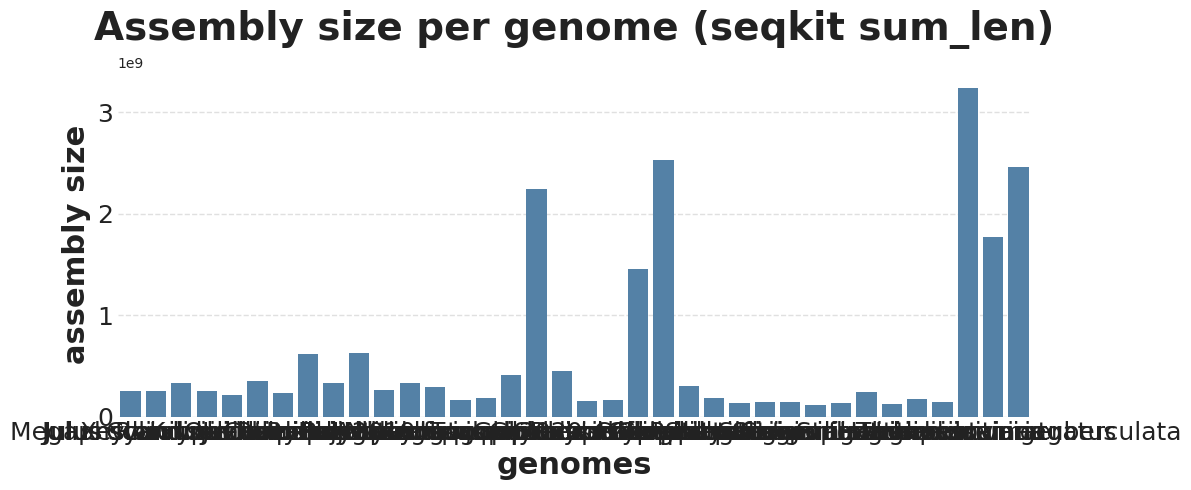

In [78]:
# Seaborn and Plotly bar charts of assembly size by genome (ordered by phylogeny)
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Use the stats dataframe built earlier
stats_df = stats.copy()
stats_df['sum_len'] = pd.to_numeric(stats_df['sum_len'], errors='coerce')

# Get species order from the phylogeny with formatted names
species_order = [tip.name for tip in phylo_with_name.get_terminals()]

# Keep only species present in stats_df
present = set(stats_df['id'])
species_order = [nm for nm in species_order if nm in present]

# Apply categorical ordering to x axis
stats_df['id'] = pd.Categorical(stats_df['id'], categories=species_order, ordered=True)
stats_df_ordered = stats_df.sort_values('id')

# Seaborn barplot with custom order
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=stats_df_ordered, x='id', y='sum_len', order=species_order, color='steelblue')

# Apply standardized styling
style_seaborn(
    ax,
    title='Assembly size per genome (seqkit sum_len)',
    subtitle=None,  # set a subtitle string here if needed
    xlabel='genomes',
    ylabel='assembly size'
)

plt.tight_layout()
plt.show()

# # Plotly bar chart with category order from phylogeny
# fig = px.bar(
#     stats_df_ordered,
#     x='id',
#     y='sum_len',
#     labels={'id': 'genomes', 'sum_len': 'assembly size'},
#     title='Assembly size per genome (seqkit sum_len)'
# )
# fig.update_layout(xaxis={'categoryorder': 'array', 'categoryarray': species_order}, xaxis_tickangle=-45)
# fig.show()

## Parse GFF files from input_dir
We will use `gffutils` to parse all `.gff` files under `input_dir` and create a consolidated table of features.

In [ ]:
# Collect all .gff files under input_dir
gff_paths = [os.path.join(input_dir, fn) for fn in os.listdir(input_dir) if fn.endswith('.gff')]

group_cols = ["genome", "type", "repeat_type", "repeat_class", "repeat_order", "repeat_superfamily", "repeat_family"]

def parse_attributes(attr):
    if pd.isna(attr):
        return {}
    return dict(
        item.split("=", 1)
        for item in attr.split(";")
        if "=" in item
    )

def process_gff(path):
    df = gffpd.read_gff3(path)

    attrs_df = df.df["attributes"].apply(parse_attributes).apply(pd.Series)
    df = pd.concat([df.df.drop(columns=["attributes"]), attrs_df], axis=1)

    name = os.path.splitext(os.path.basename(path))[0].split('_')[0]
    df.insert(0, "genome", name)

    df = df.loc[:, [
        "genome", "type", "total_length",
        "repeat_type", "repeat_class",
        "repeat_order", "repeat_superfamily", "repeat_family"
    ]]

    df["total_length"] = pd.to_numeric(df["total_length"], errors="coerce")

    # Save per-genome TSV
    out_path = f"{output_dir}/{name}_repeats.tsv"
    df.to_csv(out_path, sep="\t", index=False)

    # Summary
    summary_df = (
        df
        .groupby(group_cols, dropna=False)
        .agg(
            load=("total_length", "size"),
            coverage=("total_length", "sum"),
        )
        .reset_index()
    )

    return summary_df


In [ ]:
all_summaries = []

with ProcessPoolExecutor(max_workers=20) as executor:
    for summary_df in executor.map(process_gff, gff_paths):
        all_summaries.append(summary_df)

final_df = pd.concat(all_summaries, ignore_index=True)

In [ ]:
final_df = pd.concat(all_summaries, ignore_index=True)
# Filter out Low_complexity repeat types
final_df = final_df[final_df['repeat_type'] != 'Low_complexity']
final_df.to_csv(f"{output_dir}/all_repeats.tsv", sep="\t", index=False)

In [35]:
final_df 

,genome,type,repeat_type,repeat_class,repeat_order,repeat_superfamily,repeat_family,load,coverage
1,agaricogonopus-acrotrifoliolatus,Simple_repeat,Simple_repeat,NA,NA,NA,NA,145717,4799212
2,agaricogonopus-acrotrifoliolatus,Simple_repeat,Simple_repeat,Simple,NA,NA,NA,808,39988
3,agaricogonopus-acrotrifoliolatus,Transposable_elements,Transposable_elements,ClassI,DIRS,DIRS,NA,322,85762
4,agaricogonopus-acrotrifoliolatus,Transposable_elements,Transposable_elements,ClassI,DIRS,Ngaro,NA,85,4768
5,agaricogonopus-acrotrifoliolatus,Transposable_elements,Transposable_elements,ClassI,LINE,I,NA,245114,431287162
...,...,...,...,...,...,...,...,...,...
3385,xestoiulus-laeticollis,Transposable_elements,Transposable_elements,ClassII,Unknown,Zisupton,NA,28,6116
3386,xestoiulus-laeticollis,Transposable_elements,Transposable_elements,NA,Unspecified,NA,NA,11759,1152165
3387,xestoiulus-laeticollis,Transposable_elements,Transposable_elements,Normally Non-integrating Virus,Other,DNA_virus,NA,1,77
3388,xestoiulus-laeticollis,Transposable_elements,Transposable_elements,Satellite,Satellite,NA,NA,1798,324238


In [44]:
# Summarize final_df by genome and requested categories
import numpy as np

# Work on a copy
cat_df = final_df.copy()

# Normalize key columns
for col in ['repeat_type', 'repeat_class', 'repeat_order']:
    if col not in cat_df.columns:
        cat_df[col] = 'Unknown'
    else:
        cat_df[col] = cat_df[col].fillna('Unknown').astype(str).str.strip()

# Define category mapping
order_names = {
    'DIRS', 'LINE', 'LTR', 'PLE', 'SINE', 'Crypton', 'Helitron', 'Maverick', 'TIR'
}

# Start with Unknown
cat_df['Category'] = 'Unknown'

# TRs: Simple_repeat in repeat_type
mask_trs = (cat_df['repeat_type'] == 'Simple_repeat')
cat_df.loc[mask_trs, 'Category'] = 'TRs'

# Order-based categories (only where not already TRs)
mask_order_any = cat_df['repeat_order'].isin(order_names) & (~mask_trs)
cat_df.loc[mask_order_any, 'Category'] = cat_df.loc[mask_order_any, 'repeat_order']

# Other Class II: ClassII in repeat_class AND Unknown in repeat_order AND not yet categorized
mask_other_class2 = (
    (cat_df['Category'] == 'Unknown') &
    (cat_df['repeat_class'] == 'ClassII') &
    (cat_df['repeat_order'] == 'Unknown')
)
cat_df.loc[mask_other_class2, 'Category'] = 'Other Class II'

# Ensure numeric types for aggregation
cat_df['load'] = pd.to_numeric(cat_df['load'], errors='coerce').fillna(0)
cat_df['coverage'] = pd.to_numeric(cat_df['coverage'], errors='coerce').fillna(0)

# Aggregate by genome and Category
summary = (
    cat_df
    .groupby(['genome', 'Category'], dropna=False)
    .agg(load=('load', 'sum'), coverage=('coverage', 'sum'))
    .reset_index()
)

# Optional: enforce category order for nicer display
cat_order = ['DIRS','LINE','LTR','PLE','SINE','Crypton','Helitron','Maverick','TIR','Other Class II','Unknown','TRs']
summary['Category'] = pd.Categorical(summary['Category'], categories=cat_order, ordered=True)
summary = summary.sort_values(['genome','Category']).reset_index(drop=True)

summary

,genome,Category,load,coverage
0,agaricogonopus-acrotrifoliolatus,DIRS,407,90530
1,agaricogonopus-acrotrifoliolatus,LINE,724622,710465131
2,agaricogonopus-acrotrifoliolatus,LTR,732501,542402302
3,agaricogonopus-acrotrifoliolatus,PLE,22966,12449658
4,agaricogonopus-acrotrifoliolatus,SINE,9711,958362
...,...,...,...,...
436,xestoiulus-laeticollis,Maverick,2364,683023
437,xestoiulus-laeticollis,TIR,212103,34318276
438,xestoiulus-laeticollis,Other Class II,1581,244078
439,xestoiulus-laeticollis,Unknown,267128,34473106


In [47]:
# Plotly histograms of repeat load and coverage (%) by genome and category (ordered by phylogeny)
import plotly.express as px
import plotly.io as pio
import numpy as np

# Force a renderer that doesn't require nbformat in this environment
try:
    pio.renderers.default = 'vscode'  # inline in VS Code
except Exception:
    pio.renderers.default = 'browser'  # fallback to browser

# Prepare species order from phylogeny (names already formatted earlier)
species_order = [tip.name for tip in phylo_with_name.get_terminals()]

# Prepare plotting DataFrame: align genome names to the formatted convention
summary_plot = summary.copy()
summary_plot['genome_fmt'] = summary_plot['genome'].apply(format_plot_name)

# Keep only genomes present in the summary
present = set(summary_plot['genome_fmt'])
species_order = [nm for nm in species_order if nm in present]

# Ensure desired category ordering
cat_order = ['DIRS','LINE','LTR','PLE','SINE','Crypton','Helitron','Maverick','TIR','Other Class II','Unknown','TRs']

# Plot: Load (stacked by Category)
fig_load = px.bar(
    summary_plot,
    x='genome_fmt',
    y='load',
    color='Category',
    category_orders={'genome_fmt': species_order, 'Category': cat_order},
    labels={'genome_fmt': 'genomes', 'load': 'load', 'Category': 'Category'},
    title='Repeat load by genome and category'
)
fig_load.update_layout(barmode='stack', xaxis_tickangle=-45)
try:
    fig_load.show()
except ValueError:
    # If a renderer complains about nbformat, use browser fallback
    pio.renderers.default = 'browser'
    fig_load.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [52]:
# Compute coverage percent: coverage * 100 / sum_len (joining stats for sum_len)
sum_len_df = stats[['id', 'sum_len']].copy()
sum_len_df['sum_len'] = pd.to_numeric(sum_len_df['sum_len'], errors='coerce')

summary_plot = summary_plot.merge(
    sum_len_df.rename(columns={'id': 'genome_fmt'}),
    on='genome_fmt', how='left'
)
summary_plot['coverage'] = pd.to_numeric(summary_plot['coverage'], errors='coerce').fillna(0)
summary_plot['coverage_pct'] = np.where(
    (summary_plot['sum_len'].fillna(0) > 0),
    (summary_plot['coverage'] / summary_plot['sum_len']) * 100,
    0
)

# Plot: Coverage (%) (stacked by Category)
fig_cov = px.bar(
    summary_plot,
    x='genome_fmt',
    y='coverage_pct',
    color='Category',
    category_orders={'genome_fmt': species_order, 'Category': cat_order},
    labels={'genome_fmt': 'genomes', 'coverage_pct': 'coverage (%)', 'Category': 'Category'},
    title='Repeat coverage (%) by genome and category'
)
fig_cov.update_layout(barmode='stack', xaxis_tickangle=-45)
fig_cov.show()

MergeError: Passing 'suffixes' which cause duplicate columns {'sum_len_x'} is not allowed.